<a href="https://colab.research.google.com/github/analopez-datascience/Tableau-Esenciales/blob/main/Prueba1_tableaudocumentapi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tableaudocumentapi pandas lxml

  Preparing metadata (setup.py) ... done
  Created wheel for tableaudocumentapi: filename=tableaudocumentapi-0.11-py2.py3-none-any.whl size=16216 sha256=eac87c07709455cd5f98704721a8355c30f0fdef047f4f75237b3969aaa7b122
  Stored in directory: /root/.cache/pip/wheels/64/d6/eb/1c8ae32bb8e62fc075fe309000177898b05ad06eb2f286d04a
Successfully built tableaudocumentapi


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path_twb = '/content/drive/MyDrive/fleet_status.twb'

In [ ]:
from tableaudocumentapi import Workbook

# Abre el workbook
wb = Workbook(path_twb)

In [ ]:
path_twb = '/content/drive/MyDrive/fleet_status.twb'

In [ ]:
import pandas as pd

# Inicializa una lista para almacenar los registros
registros = []

# Itera sobre cada fuente de datos en el workbook
for ds in wb.datasources:
    # Itera sobre cada cálculo en la fuente de datos
    for calc_name, calc_formula in ds.calculations.items():
        # Añade un diccionario con los detalles del cálculo a la lista
        registros.append({
            'Datasource': ds.name,
            'Nombre del Cálculo': calc_name,
            'Fórmula': calc_formula
        })

In [ ]:
# Crea un DataFrame con los registros
df = pd.DataFrame(registros)

# Muestra las primeras 10 filas del DataFrame
df.head(25)

,Datasource,Nombre del Cálculo,Fórmula
0,Parameters,[Cd Booking Status Lv1 Parámetro (copia)],------ FIELD Last week (week param/Last week/[...
1,Parameters,[Dt Sales Parámetro],------ FIELD Sales from (Sales from/None/[Dt S...
2,Parameters,[Flight Month Selector (copia)_111717423954948...,------ FIELD Flight Month Selector (Flight Mon...
3,Parameters,[Granuality (copia 2)],------ FIELD Eventos/Tiempo (Eventos/Tiempo/No...
4,Parameters,[Granuality (copia)],------ FIELD Historical Period (Historical Per...
5,Parameters,[Granularity Equivalent (copy)],------ FIELD Actives at 8h (Graph Selector/Act...
6,Parameters,[Id Workorder Parámetro],------ FIELD UTC (Time Zone/UTC/[Id Workorder ...
7,Parameters,[KPI (copia)_1586392972722339840],------ FIELD Revenue (IG_KPI param/Revenue/[KP...
8,Parameters,[Orig/Dest/Segment (copia)],------ FIELD Filter End Date (Filter End Date/...
9,Parameters,[Parameter 1 1],------ FIELD MEL Tendency Hour (MEL Tendency H...


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['index']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'index'}, axis=1)
              .sort_values('index', ascending=True))
  xs = counted['index']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_1.sort_values('index', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_2['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

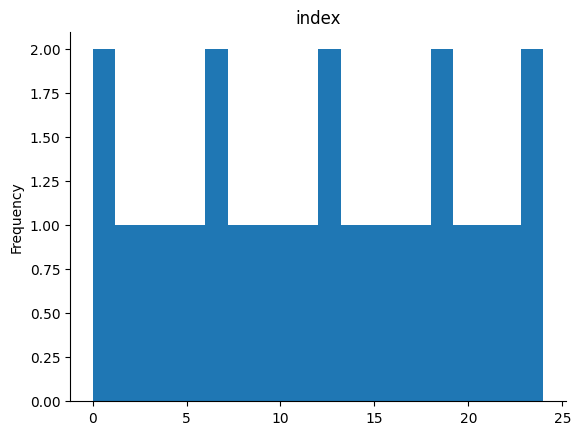

In [ ]:
from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
# Exporta los cálculos a un archivo CSV
df.to_csv('todos_calculos.csv', index=False, encoding='utf-8-sig')

In [ ]:
df.head(100)

,Datasource,Nombre del Cálculo,Fórmula
0,Parameters,[Cd Booking Status Lv1 Parámetro (copia)],------ FIELD Last week (week param/Last week/[...
1,Parameters,[Dt Sales Parámetro],------ FIELD Sales from (Sales from/None/[Dt S...
2,Parameters,[Flight Month Selector (copia)_111717423954948...,------ FIELD Flight Month Selector (Flight Mon...
3,Parameters,[Granuality (copia 2)],------ FIELD Eventos/Tiempo (Eventos/Tiempo/No...
4,Parameters,[Granuality (copia)],------ FIELD Historical Period (Historical Per...
...,...,...,...
95,federated.0xku7n31lhfk9a197q5of0vus84o,[Parameter 5],------ FIELD MEL ITEM & CDL WO TENDENCY (Selec...
96,federated.0xku7n31lhfk9a197q5of0vus84o,[Parámetro 1 1],------ FIELD Deferred Defects (Deferred Defect...
97,federated.0xku7n31lhfk9a197q5of0vus84o,[Parámetro 2 1],------ FIELD 24h performance (Day Period/24h p...
98,federated.0xku7n31lhfk9a197q5of0vus84o,[Selected Period (copy)],------ FIELD Current Year (Selected Dates/Curr...


In [ ]:
# Muestra las columnas del DataFrame
print(df.columns)

Index(['Datasource', 'Nombre del Cálculo', 'Fórmula'], dtype='object')


In [ ]:
!pip install openpyxl

In [ ]:
# Exporta el DataFrame a un archivo Excel
df.to_excel('campos_calculados.xlsx', index=False, engine='openpyxl')

In [ ]:
from google.colab import files
files.download('campos_calculados.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import xml.etree.ElementTree as ET
import pandas as pd

# 1) Carga el XML
tree = ET.parse('/content/drive/MyDrive/fleet_status.twb')
root = tree.getroot()

registros = []
# 2) Recorre cada datasource y sus columnas
for ds in root.findall('.//datasource'):
    ds_name = ds.get('name')
    for col in ds.findall('column'):
        # atributos de la columna
        caption    = col.get('caption')
        datatype   = col.get('datatype')
        role       = col.get('role')
        agg        = col.get('default-aggregation')
        # Busca un cálculo dentro de la columna (si existe)
        calc_node  = col.find('calculation')
        formula    = calc_node.text if calc_node is not None else None
        # Guarda todo
        registros.append({
            'Datasource': ds_name,
            'Campo':      caption,
            'Tipo':       datatype,
            'Rol':        role,
            'Agregación': agg,
            'Fórmula':    formula
        })

# 3) Convierte a DataFrame y exporta a Excel
df = pd.DataFrame(registros)
df.to_excel('todos_los_campos.xlsx', index=False, engine='openpyxl')
print("Listo: escribí todos_los_campos.xlsx")

Listo: escribí todos_los_campos.xlsx


In [ ]:
from google.colab import files
files.download('todos_los_campos.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install tableaudocumentapi pandas openpyxl

from tableaudocumentapi import Workbook
import pandas as pd

# 1) Abre tu TWB
wb = Workbook('/content/drive/MyDrive/fleet_status.twb')

registros = []
# 2) Recorre cada datasource y cada campo/calculación
for ds in wb.datasources:
    for fld in ds.fields:
        # Campos nativos y calculados
        registros.append({
            'Datasource':      ds.name,
            'Nombre campo':    fld.name,
            'Fórmula (si)':    getattr(fld, 'formula', None),
            'Datatype':        fld.datatype,
            'Role':            fld.role,
            'Agregación':      fld.default_aggregation
        })

# 3) DataFrame y Excel
df = pd.DataFrame(registros)
df.to_excel('fields_via_api.xlsx', index=False, engine='openpyxl')
print("Generado fields_via_api.xlsx")

AttributeError: 'str' object has no attribute 'name'